## End 2 End ML life cycle

    - Problem definition
    - Data Collection
    - Data Cleaning and preprocessing
    - EDA
    - Feature Engineering & selection
    - Model Selection
    - Model Training
    - Model Evaluation and Tuning
    - Model Deployment
    - Montoring & Maintenance

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

### 1. Problem Definition

In [3]:
# Goal: Classify movie reviews as positive (1) or negative (0) based on text sentiment.
# Application: This can be used for review analysis, customer feedback systems, or recommendation engines.

### 2. Data Collection

#### The dataset consists of 20 manually curated movie reviews with sentiment labels (positive,negative).
#### In a real-world scenario, data might be scraped from IMDb, Rotten Tomatoes, or collected via APIs.
    https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews?resource=download

In [4]:
data_path = "IMDB_Dataset.csv"
df = pd.read_csv(data_path)
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


### 3. Data Cleaning and Preprocessing

#### Convert text into numerical representations using TF-IDF Vectorization.
#### Removes stop words, punctuation, and converts words to lowercase
                                                 bad	is	love	movie	this
                 Review 1 ("I love this movie")	0.000	0.000	0.705	0.502	0.502
                 Review 2 ("This movie is bad")	0.576	0.576	0.000	0.410	0.410

In [5]:
vectorizer = TfidfVectorizer(stop_words=None)
X = vectorizer.fit_transform(df['review'])
y = df['sentiment']

In [6]:
### feature names

In [7]:
feature_names = vectorizer.get_feature_names_out()
print("Features ")
print(feature_names)
print("Length")
print(len(feature_names))

Features 
['00' '000' '00000000000' ... 'żmijewski' 'יגאל' 'כרמון']
Length
101895


In [8]:
X.todense()[0]

matrix([[0., 0., 0., ..., 0., 0., 0.]])

In [9]:
y[0:5]

0    positive
1    positive
2    positive
3    negative
4    positive
Name: sentiment, dtype: object

In [10]:
### 4. Exploratory Data Analysis (EDA)

In [11]:
#### Check the distribution of positive vs. negative reviews

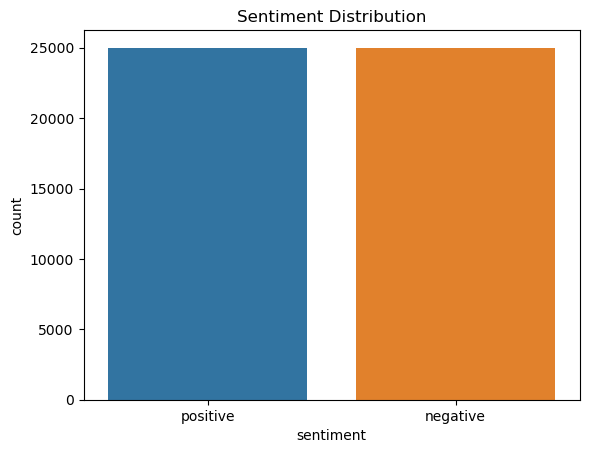

In [12]:
sns.countplot(x=df["sentiment"])
plt.title("Sentiment Distribution")
plt.show()

In [13]:
from wordcloud import WordCloud
# Generate Word Cloud
text = " ".join(df['review'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Plot Word Cloud
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud for Movie Reviews")
plt.show()

[('the', 568735), ('a', 306960), ('and', 301919), ('of', 283625), ('to', 261850), ('is', 203056), ('in', 169981), ('I', 132498), ('that', 126818), ('this', 113726)]


#### 5. Feature Engineering & Selection
        We used TF-IDF to select important words, but additional techniques like N-grams, POS tagging, and word embeddings (Word2Vec, BERT) can be used.

### 6. Model Selection
        using Random forest model
        Train and Test split - 80% and 20%

In [14]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier()
model

RandomForestClassifier()

### 7. Model Training

In [15]:
model.fit(X_train, y_train)

RandomForestClassifier()

#### save the model and the vectorizer

In [56]:
joblib.dump(model, 'sentiment_model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')

['old_data_distribution.pkl']

### 8. Model Evaluation and Tuning
    Performance Metrics: Accuracy, Precision, Recall, F1-score

In [16]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8444
Classification Report:
               precision    recall  f1-score   support

    negative       0.84      0.85      0.84      4961
    positive       0.85      0.84      0.84      5039

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000

Confusion Matrix:
 [[4228  733]
 [ 823 4216]]


In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],   # Number of trees in the forest
    'max_depth': [None, 10, 20],      # Maximum depth of each tree (None means nodes expand until leaves are pure)
    'min_samples_split': [2, 5, 10],  # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]     # Minimum samples required to be at a leaf node
}
grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Best Model
model = grid_search.best_estimator_

# 7. Model Training
model.fit(X_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


In [ ]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

### 9. Model Deployment (FastAPI Backend & Streamlit UI)
    FastAPI serves the model via an API endpoint:
    movies_fastapi_app.py
    Streamlit act as UI for movie reviewing app
    movies_stramlit_app.py

### 10. Monitoring & Maintenance
    Monitor Model Performance:

    Set up logging (e.g., FastAPI logs, monitoring dashboards).
    Track accuracy drift by periodically checking real-world data vs. model predictions.
    Model Retraining Strategy:

    Periodic retraining with fresh user reviews.
    Active learning: Ask users for feedback (e.g., "Was this prediction correct?").
    Deployment Maintenance:

    API uptime monitoring using Prometheus/Grafana.
    Dockerize and deploy using Kubernetes or AWS Lambda for scalability.
